In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import (Dense, Flatten, Reshape, Convolution2D, MaxPooling2D, AveragePooling2D, Concatenate, InputLayer,
                                        ## data augmentation:
                                        Rescaling, RandomRotation, RandomFlip, RandomZoom, RandomTranslation, RandomBrightness,
                                        ## regularisation:
                                        Dropout
                                        ) 

from keras.datasets import fashion_mnist

import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import pathlib

In [11]:
## plot and evaluate model

def plot_cm_display(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    
    #plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    CM = ConfusionMatrixDisplay(cm)
    CM.plot()
    #sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
        if metric == 'accuracy':
            plt.ylim(0,1.1)
    plt.show()

In [8]:
data_dir = pathlib.Path("CIFAKE")

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / "train",
    image_size=(32, 32),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / "test",
    image_size=(32, 32),
    batch_size=32,
    shuffle=False
)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [7]:
def dataset_to_numpy(ds):
    images = []
    labels = []
    for batch_images, batch_labels in ds:
        images.append(batch_images.numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(images), np.concatenate(labels)

In [21]:
# Convert datasets to NumPy arrays
X_train, y_train = dataset_to_numpy(train_ds)
X_test, y_test = dataset_to_numpy(test_ds)

In [ ]:
print('X_train shape:', X_train.shape)   # 100_000 lignes/number of images, 32x32 pixels, 3 channels (R, G, B)
print('y_train shape:', y_train.shape)   # 100_000 labels
print('X_test shape:', X_test.shape)    # 20_000 lignes/number of images, 32x32 pixels, 3 channels (R, G, B)
print('y_test shape:', y_test.shape)    # 20_000 labels

X_train shape: (100000, 32, 32, 3)
y_train shape: (100000,)
X_test shape: (20000, 32, 32, 3)
y_test shape: (20000,)


In [12]:
X_train.dtype

dtype('float32')

In [13]:
np.sum(np.isnan(X_train),axis=None)

np.int64(0)

### Visualize a few samples per class

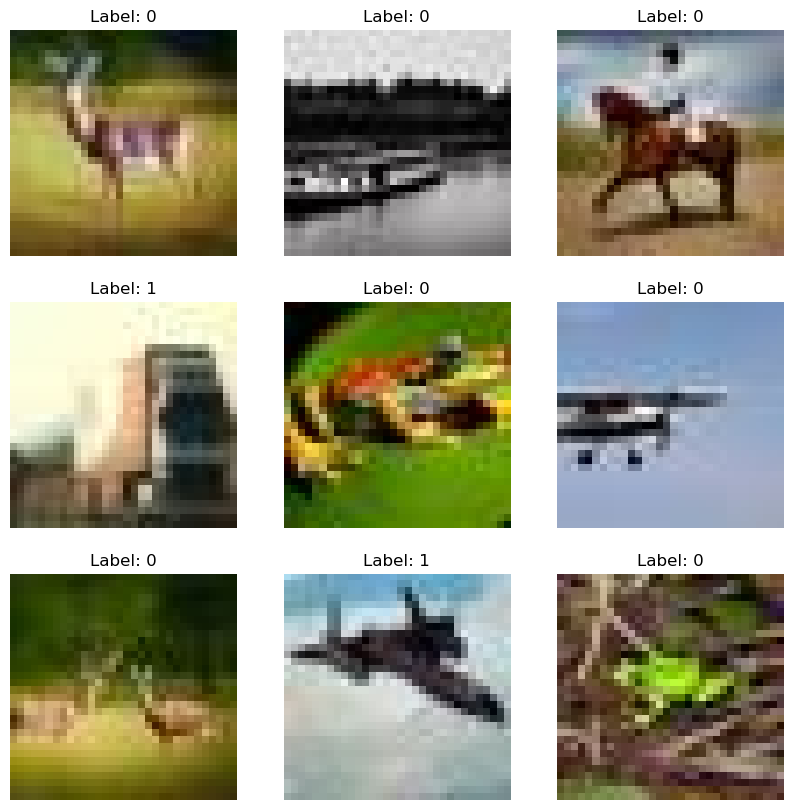

In [ ]:
def show_batch(ds):
    images, labels = next(iter(ds))
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(f'Label: {labels[i].numpy()}')
        plt.axis('off')

show_batch(train_ds)

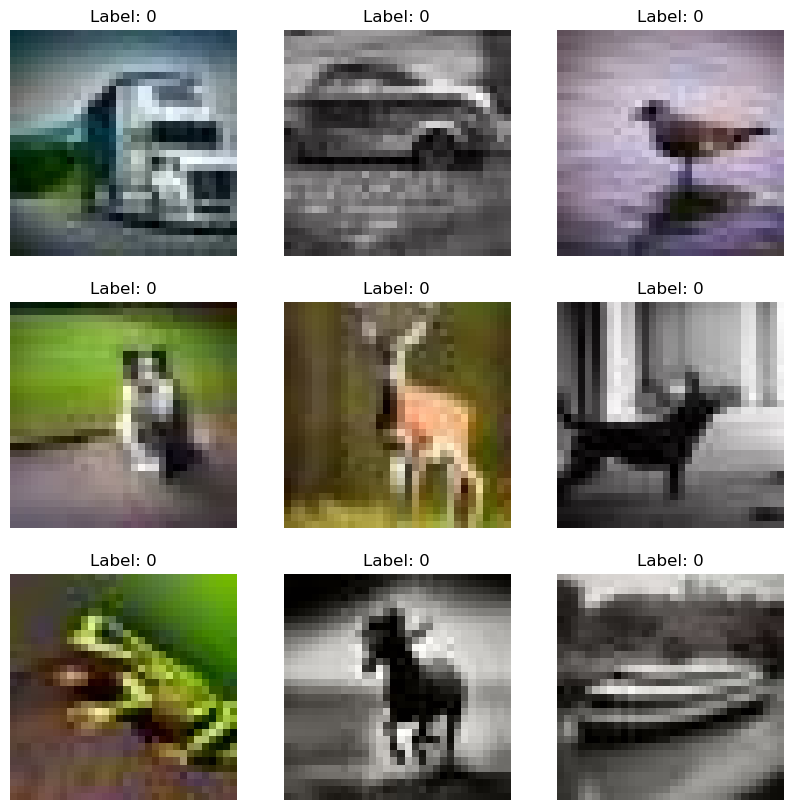

In [15]:
show_batch(test_ds)

### Check image batch shape

In [16]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 32, 32, 3)


32 → number of images in the batch

32 → image height

32 → image width

3 → RGB channels

### Check class distribution

In [17]:
_, y_train = dataset_to_numpy(train_ds)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(50000), np.int32(1): np.int64(50000)}


index 0 → 'FAKE'

index 1 → 'REAL'

Check class distribution: perfectly balanced.

### Check pixel value ranges

In [ ]:
print('Min:', X_train.min(), 'Max:', X_train.max())

Min: 0.0 Max: 255.0


In [23]:
X_test = X_test/np.max(X_test,axis=None)

### Data augmentation

In [ ]:
data_augmentation = keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.05),          # ~5% rotation (≈ ±9°)
    RandomZoom(0.1),               # slight zoom
    RandomTranslation(0.1, 0.1),   # small shifts
    RandomBrightness(factor=0.1),  # mild brightness change
], name='data_augmentation')

### Model using Keras Functional API

In [ ]:
IMG_SHAPE=(32, 32, 3)
ACTIVATION='relu'

inputs = keras.Input(IMG_SHAPE)

x = data_augmentation(inputs)   # apply data augmentation as a preprocessing layer at the start

x = Rescaling(1./255)(x)      # normalize after augmentation

# Example model:
x = Convolution2D(32, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Convolution2D(64, 3, activation=ACTIVATION)(x)
x = MaxPooling2D()(x)
x = Flatten()(x)
x = Dense(64, activation=ACTIVATION)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)